<a href="https://colab.research.google.com/github/lankelasharanya04-crypto/datascience_tasks/blob/main/Analysing_Ecommerce_sales_drop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysing Ecommerce sales drop

Company Scenario (Flipkart/amazon) :

we are seeing a drop in revenue find the reason and suggest actions

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# data loading
customers = pd.read_csv("/content/customers.csv")
orders = pd.read_csv("/content/orders.csv")
products = pd.read_csv("/content/products.csv")

In [3]:
orders


,order_id,customer_id,product_id,order_date,city,quantity
0,1,101,201,2024-01-05,Hyderabad,1
1,2,102,202,2024-01-06,Bangalore,2
2,3,103,203,2024-01-10,Chennai,1
3,4,101,202,2024-02-12,Hyderabad,1
4,5,104,204,2024-02-18,Bangalore,3
5,6,105,201,2024-03-05,Chennai,1
6,7,102,203,2024-03-15,Bangalore,1
7,8,106,205,2024-04-02,Hyderabad,2
8,9,107,202,2024-04-10,Chennai,1
9,10,108,204,2024-04-18,Bangalore,2


In [4]:
customers

,customer_id,customer_name,signup_date
0,101,Ravi,2023-11-10
1,102,Sneha,2023-12-01
2,103,Amit,2023-12-15
3,104,Pooja,2024-01-05
4,105,Kiran,2024-01-20
5,106,Arjun,2024-02-02
6,107,Divya,2024-02-15
7,108,Rahul,2024-03-01
8,109,Meena,2024-03-10
9,110,Vikram,2024-04-01


In [5]:
df = pd.merge(customers,orders,on = "customer_id",how = "inner")
df = pd.merge(df,products,on = "product_id",how = "inner")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    20 non-null     int64 
 1   customer_name  20 non-null     object
 2   signup_date    20 non-null     object
 3   order_id       20 non-null     int64 
 4   product_id     20 non-null     int64 
 5   order_date     20 non-null     object
 6   city           20 non-null     object
 7   quantity       20 non-null     int64 
 8   product_name   20 non-null     object
 9   category       20 non-null     object
 10  price          20 non-null     int64 
dtypes: int64(5), object(6)
memory usage: 1.8+ KB


In [7]:
# converting object data type to date datatype
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['order_date'] = pd.to_datetime(df['order_date'])

In [8]:
# creating the revenue col
df['Revenue'] = df['price']*df['quantity']

In [10]:
df.head()

,customer_id,customer_name,signup_date,order_id,product_id,order_date,city,quantity,product_name,category,price,Revenue
0,101,Ravi,2023-11-10,1,201,2024-01-05,Hyderabad,1,Laptop,Electronics,70000,70000
1,101,Ravi,2023-11-10,4,202,2024-02-12,Hyderabad,1,Mobile,Electronics,20000,20000
2,101,Ravi,2023-11-10,11,201,2024-05-05,Hyderabad,1,Laptop,Electronics,70000,70000
3,102,Sneha,2023-12-01,2,202,2024-01-06,Bangalore,2,Mobile,Electronics,20000,40000
4,102,Sneha,2023-12-01,7,203,2024-03-15,Bangalore,1,Tablet,Electronics,15000,15000


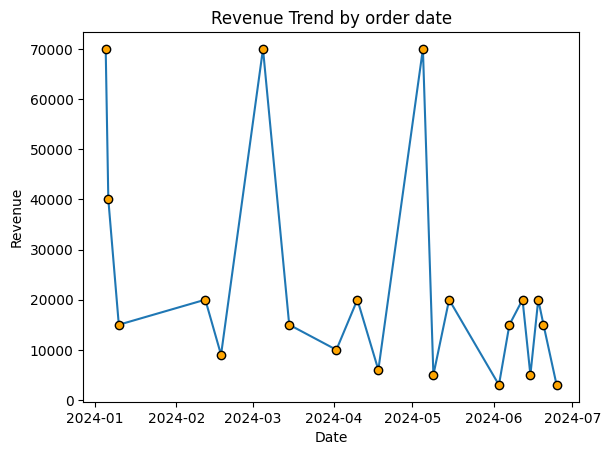

,order_date,Revenue
0,2024-01-05,70000
1,2024-01-06,40000
2,2024-01-10,15000
3,2024-02-12,20000
4,2024-02-18,9000


In [15]:
#revenue trend by orderdate
revenue=df.groupby('order_date')['Revenue'].sum()
revenue =pd.DataFrame(revenue).reset_index()
plt.plot(revenue['order_date'],revenue['Revenue'],marker="o",mfc="orange",mec="black")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Trend by order date")
plt.show()
revenue.head()

the revenue is very less in the last two months(mid may,june and july )

In [16]:
df["city"].unique()

array(['Hyderabad', 'Bangalore', 'Chennai'], dtype=object)

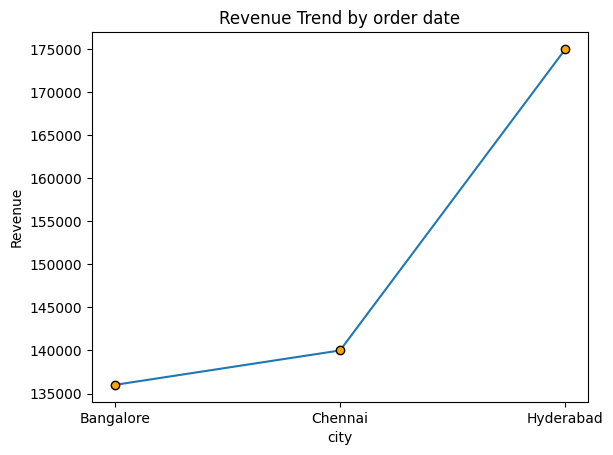

,city,Revenue
0,Bangalore,136000
1,Chennai,140000
2,Hyderabad,175000


In [17]:
#revenue trend by city
revenue=df.groupby('city')['Revenue'].sum()
revenue =pd.DataFrame(revenue).reset_index()
plt.plot(revenue['city'],revenue['Revenue'],marker="o",mfc="orange",mec="black")
plt.xlabel("city")
plt.ylabel("Revenue")
plt.title("Revenue Trend by order date")
plt.show()
revenue.head()

revenue is dropping in bengaluru

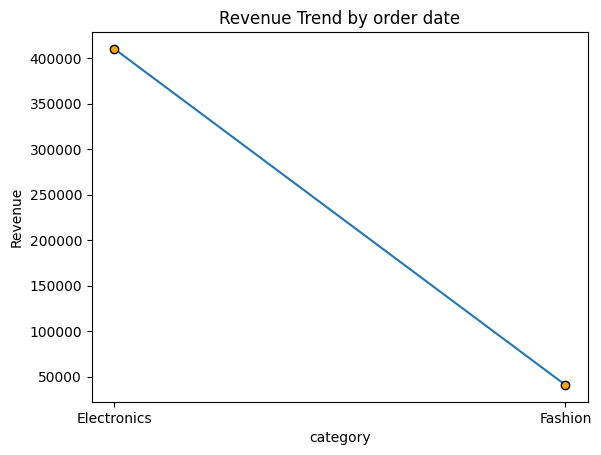

,category,Revenue
0,Electronics,410000
1,Fashion,41000


In [18]:
#revenue trend by category
revenue=df.groupby('category')['Revenue'].sum()
revenue =pd.DataFrame(revenue).reset_index()
plt.plot(revenue['category'],revenue['Revenue'],marker="o",mfc="orange",mec="black")
plt.xlabel("category")
plt.ylabel("Revenue")
plt.title("Revenue Trend by order date")
plt.show()
revenue.head()

in fashion category the revenue got dropped

In [21]:
#count customers  based on order_id(count of orders per customer)
revenue=df.groupby('customer_id')['order_id'].count()
revenue =pd.DataFrame(revenue)
revenue

,order_id
customer_id,
101,3
102,2
103,2
104,2
105,1
106,1
107,1
108,1
109,1


most of the customers are ordering less

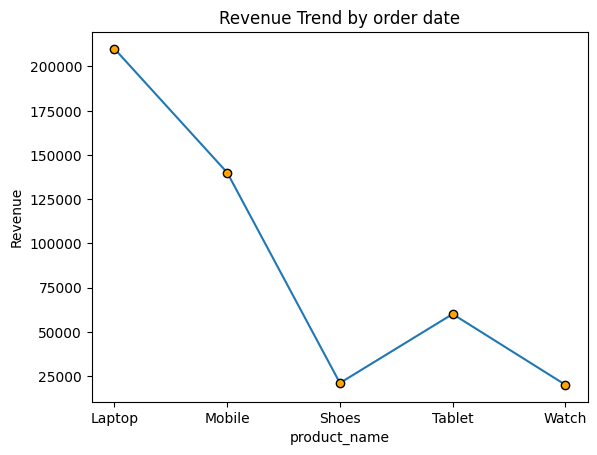

,product_name,Revenue
0,Laptop,210000
1,Mobile,140000
2,Shoes,21000
3,Tablet,60000
4,Watch,20000


In [22]:
#groupby based on product name
#revenue trend by product name
revenue=df.groupby('product_name')['Revenue'].sum()
revenue =pd.DataFrame(revenue).reset_index()
plt.plot(revenue['product_name'],revenue['Revenue'],marker="o",mfc="orange",mec="black")
plt.xlabel("product_name")
plt.ylabel("Revenue")
plt.title("Revenue Trend by order date")
plt.show()
revenue.head()

revenue is very less for shoes and watch

#insights :
1->the revenue is very less in the last two months(mid may,june and july )

2->revenue is dropping in bengaluru

3->fashion category recorded less revenue

4->most of the customers are ordering less

5->revenue is very less for shoes and watch

#recommendations:
1.Marketing should be done in banglore
2.proviode discounts for shoe and watch
3.coupens,discount,loyalty program for repeated customers
